# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from scipy import stats
from scipy.stats import zscore

from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?gid=2020477971&single=true&output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?gid=2020477971&single=true&output=csv'
data = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
data.head(5)

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
data.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
agg_result = data.groupby(["CustomerOccupation", "Channel", "TransactionType"]).agg({
    "TransactionAmount": "mean",
    "AccountBalance": ["min", "mean"],
    "CustomerAge": "mean"
}).unstack()

agg_result

TransactionAmount             AccountBalance  \
                                        mean                        min   
TransactionType                       Credit       Debit         Credit   
CustomerOccupation Channel                                                
Doctor             ATM            303.410588  296.847231         185.87   
                   Branch         317.194074  284.206968         184.72   
                   Online         314.324754  277.853760         509.45   
Engineer           ATM            273.981053  294.140058         323.69   
                   Branch         305.233448  246.423484         233.21   
                   Online         280.810000  321.292365         478.23   
Retired            ATM            272.912308  305.848820        1733.34   
                   Branch         298.131791  317.165639        1047.28   
                   Online         278.305079  278.852149        1006.12   
Student            ATM            389.042609  328.192821         239.12   
                   Branch         345.925082  270.010382         105.01   
                   Online         311.737692  317.808312         125.85   

                                                               CustomerAge  \
                                             mean                     mean   
TransactionType               Debit        Credit        Debit      Credit   
CustomerOccupation Channel                                                   
Doctor             ATM       207.10   8661.917059  9024.762487   51.352941   
                   Branch    120.89   9362.188393  8891.137161   51.696429   
                   Online    234.41  10234.924262  8302.418000   48.311475   
Engineer           ATM       112.76   4909.507778  5261.414471   45.578947   
                   Branch    319.04   5763.359649  5693.157763   43.087719   
                   Online    438.75   5757.515789  5477.820400   44.178571   
Retired            ATM      1035.22   4532.610000  4428.541341   64.857143   
                   Branch   1061.69   4152.704118  4878.878456   65.652174   
                   Online   1014.63   4403.138571  4493.662231   66.419355   
Student            ATM       136.74   1226.535217  1588.723041   23.739130   
                   Branch    117.98   1425.591803  1632.890566   23.532258   
                   Online    101.25   2001.029231  1434.436623   23.078431   

                                       
                                       
TransactionType                 Debit  
CustomerOccupation Channel             
Doctor             ATM      50.762887  
                   Branch   49.167742  
                   Online   48.385827  
Engineer           ATM      42.803468  
                   Branch   41.896104  
                   Online   42.113333  
Retired            ATM      64.826816  
                   Branch   65.187970  
                   Online   65.940678  
Student            ATM      22.842640  
                   Branch   23.107595  
                   Online   23.096774

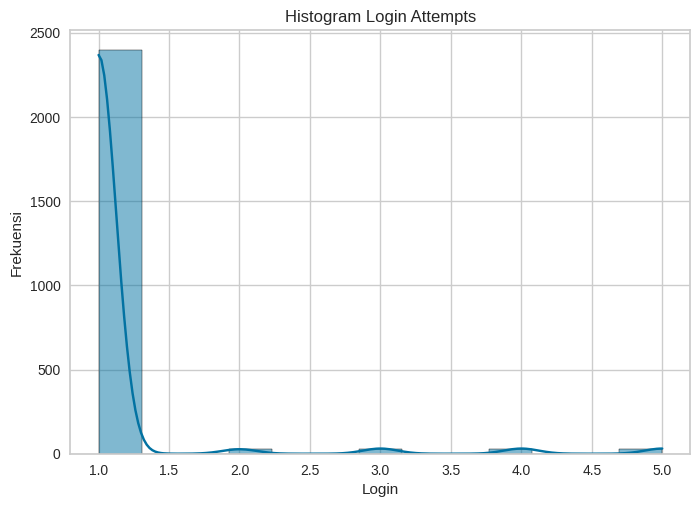

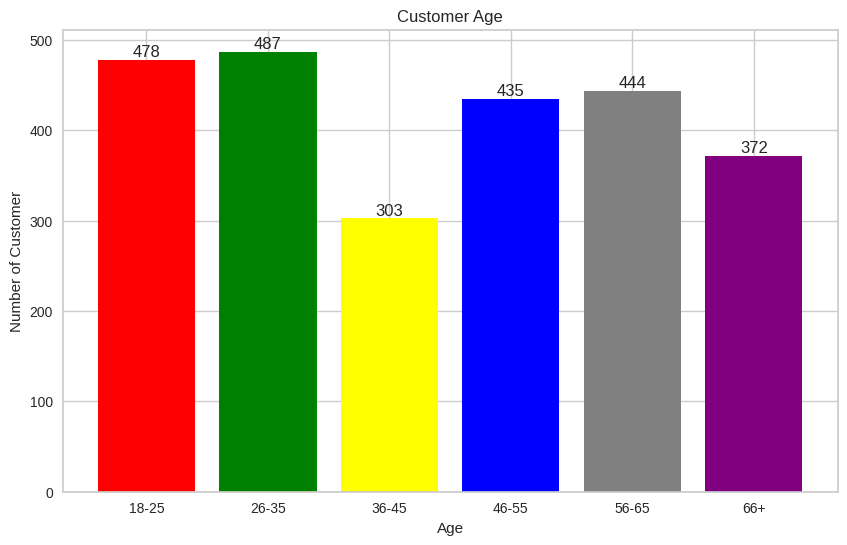

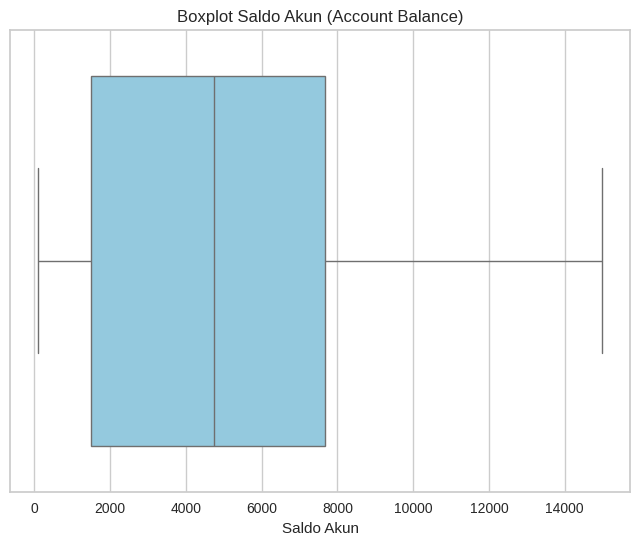

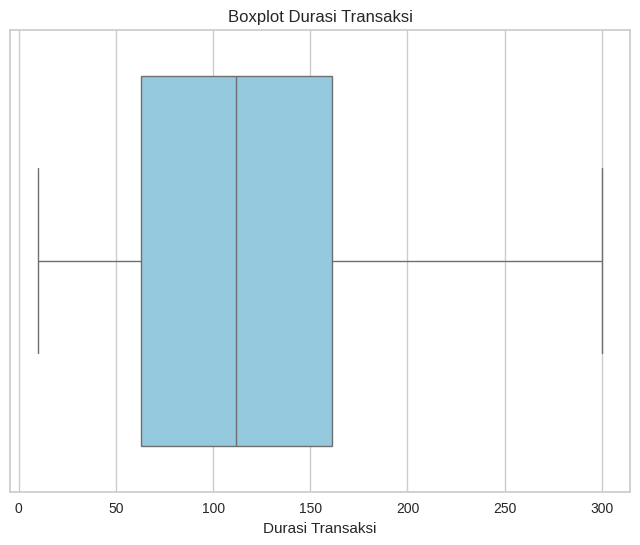

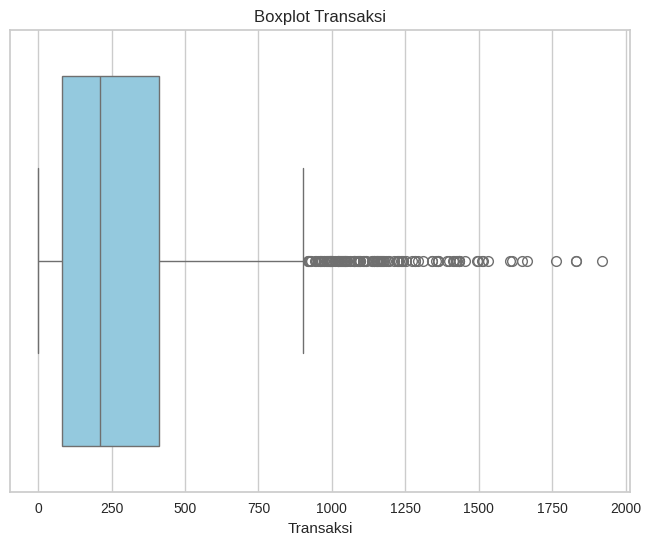

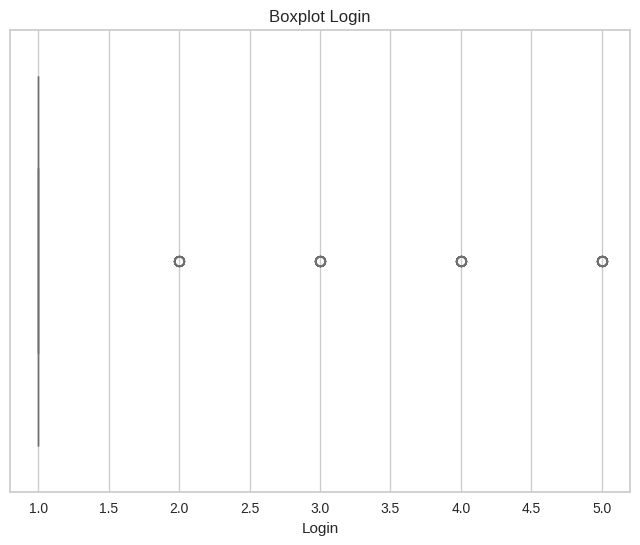

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
sns.histplot(data['LoginAttempts'], kde=True)
plt.title('Histogram Login Attempts')
plt.xlabel('Login')
plt.ylabel('Frekuensi')

age18_25 = data[(data['CustomerAge'] >= 18) & (data['CustomerAge'] <= 25)]
age26_35 = data[(data['CustomerAge'] >= 26) & (data['CustomerAge'] <= 35)]
age36_45 = data[(data['CustomerAge'] >= 36) & (data['CustomerAge'] <= 45)]
age46_55 = data[(data['CustomerAge'] >= 46) & (data['CustomerAge'] <= 55)]
age56_65 = data[(data['CustomerAge'] >= 56) & (data['CustomerAge'] <= 65)]
age66 = data[data['CustomerAge'] >= 66]

x = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age56_65.values), len(age66.values)]

plt.figure(figsize=(10,6))
plt.bar(x, y, color = ["red", "green", "yellow", "blue", "grey", "purple"])
plt.title("Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customer")

for i in range(len(x)):
    plt.text(i, y[i], y[i], ha='center', va='bottom')

plt.figure(figsize=(8, 6))
sns.boxplot(x=data['AccountBalance'], color='skyblue')
plt.title('Boxplot Saldo Akun (Account Balance)')
plt.xlabel('Saldo Akun')

plt.figure(figsize=(8, 6))
sns.boxplot(x=data['TransactionDuration'], color='skyblue')
plt.title('Boxplot Durasi Transaksi')
plt.xlabel('Durasi Transaksi')

plt.figure(figsize=(8, 6))
sns.boxplot(x=data['TransactionAmount'], color='skyblue')
plt.title('Boxplot Transaksi')
plt.xlabel('Transaksi')

plt.figure(figsize=(8, 6))
sns.boxplot(x=data['LoginAttempts'], color='skyblue')
plt.title('Boxplot Login')
plt.xlabel('Login')

plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

/tmp/ipython-input-8-3840715466.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CustomerOccupation'].fillna(value="Doctor", inplace=True)


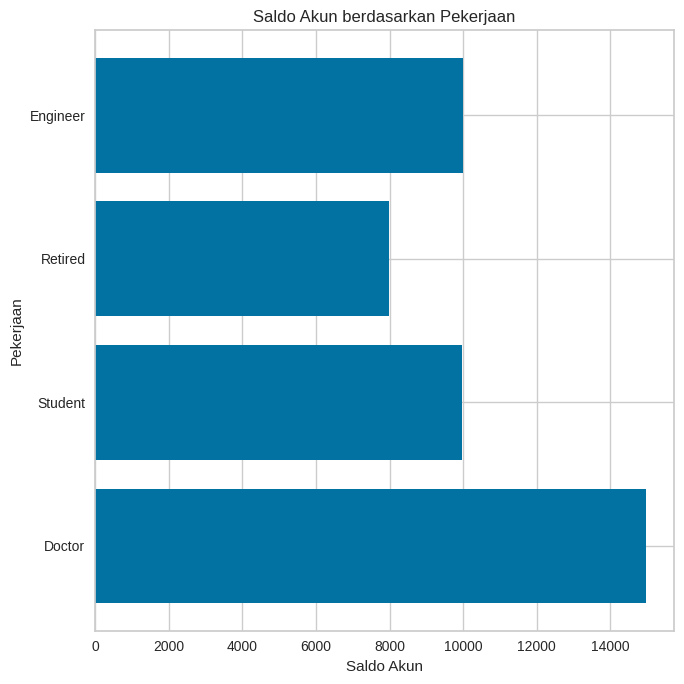

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(7, 7))

mean_saldo_pekerjaan = data.groupby('CustomerOccupation')['AccountBalance'].mean()

data['CustomerOccupation'].value_counts()

data['CustomerOccupation'].fillna(value="Doctor", inplace=True)

plt.barh(data['CustomerOccupation'], data['AccountBalance'])
plt.xlabel('Saldo Akun')
plt.ylabel('Pekerjaan')
plt.title('Saldo Akun berdasarkan Pekerjaan')
plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [9]:
# Mengecek dataset menggunakan isnull().sum()
data.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()
data.duplicated().sum()

np.int64(21)

In [11]:
# capping nilai terlebih dahulu
data_kategorik = data.select_dtypes(include=['object'])
data_numerik = data.select_dtypes(exclude=['object'])

def capping(data_numerik, column, lower_quantile=0.05, upper_quantile=0.95):
  q_low = data_numerik[column].quantile(lower_quantile)
  q_high = data_numerik[column].quantile(upper_quantile)

  new_col = column + "_capped"

  data_numerik[new_col] = data_numerik[column].clip(lower=q_low, upper=q_high)

  print(f'Capping untuk kolom "{column}":')
  print(f'- Quantile {int(lower_quantile*100)}%: {q_low:.2f}')
  print(f'- Quantile {int(upper_quantile*100)}%: {q_high:.2f}')
  return data_numerik

capping_transaksi = capping(data_numerik, "TransactionAmount")

Capping untuk kolom "TransactionAmount":
- Quantile 5%: 16.05
- Quantile 95%: 878.22


In [12]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
data_drop = ['TransactionID', 'AccountID','DeviceID','IP Address','MerchantID']

for column in data_drop:
  data_kategorik.drop(column, axis=1, inplace=True)

In [13]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.
data_encoded = data_kategorik.copy()

fiture_date = ['TransactionDate', 'PreviousTransactionDate']

for column in fiture_date:
  data_encoded[column] = pd.to_datetime(data_encoded[column])

data_encoded['TransactionDate_clean'] = data_encoded['TransactionDate'].dt.hour
data_encoded['PreviousTransactionDate_clean'] = data_encoded['PreviousTransactionDate'].dt.hour

kolom_kategorikal = ['CustomerOccupation', 'Channel', 'TransactionType', 'Location']

df_encoded = pd.get_dummies(data_encoded, columns=kolom_kategorikal, dtype=int)

df_encoded.head(5)

,PreviousTransactionDate,TransactionDate,TransactionDate_clean,PreviousTransactionDate_clean,CustomerOccupation_Doctor,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,Channel_ATM,Channel_Branch,...,Location_Raleigh,Location_Sacramento,Location_San Antonio,Location_San Diego,Location_San Francisco,Location_San Jose,Location_Seattle,Location_Tucson,Location_Virginia Beach,Location_Washington
0,2023-04-11 16:29:14,2024-11-04 08:08:08,8.0,16.0,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,2023-06-27 16:44:19,2024-11-04 08:09:35,8.0,16.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2023-07-10 18:16:08,2024-11-04 08:07:04,8.0,18.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2023-05-05 16:32:11,2024-11-04 08:09:06,8.0,16.0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2023-10-16 17:51:24,2024-11-04 08:06:39,8.0,17.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
# ____.columns.tolist()
data_kategorik.columns.tolist()

['PreviousTransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerOccupation',
 'TransactionDate']

In [15]:
data_numerik.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TransactionAmount         2511 non-null   float64
 1   CustomerAge               2519 non-null   float64
 2   TransactionDuration       2511 non-null   float64
 3   LoginAttempts             2516 non-null   float64
 4   AccountBalance            2510 non-null   float64
 5   TransactionAmount_capped  2511 non-null   float64
dtypes: float64(6)
memory usage: 119.1 KB


(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [16]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
for fill_numerik in data_numerik:
  data_numerik[fill_numerik].fillna(data_numerik[fill_numerik].mean(), inplace=True)

/tmp/ipython-input-16-3179276469.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_numerik[fill_numerik].fillna(data_numerik[fill_numerik].mean(), inplace=True)


In [17]:
# Menghapus data duplikat menggunakan drop_duplicates().
data_semi_clean = pd.concat([df_encoded, data_numerik],axis=1)
data_semi_clean.drop_duplicates(inplace=True)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [18]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
data_clean = data_semi_clean.copy()
data_clean.drop(
    ['TransactionAmount',
     'TransactionDate',
     'PreviousTransactionDate'], axis=1, inplace=True)

data_clean_use = data_clean[['CustomerAge','AccountBalance','TransactionAmount_capped', 'LoginAttempts', 'TransactionDuration']]
data_clean_use.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2515 entries, 0 to 2535
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerAge               2515 non-null   float64
 1   AccountBalance            2515 non-null   float64
 2   TransactionAmount_capped  2515 non-null   float64
 3   LoginAttempts             2515 non-null   float64
 4   TransactionDuration       2515 non-null   float64
dtypes: float64(5)
memory usage: 117.9 KB


In [19]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
min_max_scaler = MinMaxScaler()
data_clean_scaling = min_max_scaler.fit_transform(data_clean_use)
dcs_df = pd.DataFrame(data_clean_scaling, columns=data_clean_use.columns)
dcs_df.head()

,CustomerAge,AccountBalance,TransactionAmount_capped,LoginAttempts,TransactionDuration
0,0.838710,0.336832,0.000000,0.0,0.244828
1,0.806452,0.918055,0.417768,0.0,0.451724
2,0.016129,0.068637,0.127858,0.0,0.158621
3,0.129032,0.569198,0.195374,0.0,0.051724
4,0.430297,0.492591,0.000000,0.0,0.648276


In [20]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.
bined_dataset = data_clean_use.copy()

bined_dataset['Age_Binned'] = pd.cut(bined_dataset['CustomerAge'], bins=5, labels=['Very Young', 'Young', 'Adult', 'Mature', 'Senior'])
bined_dataset['Balance_Binned'] = pd.cut(bined_dataset['AccountBalance'], bins=5, labels=['Sangat Rendah', 'Rendah', 'Menengah', 'Tinggi', 'Sangat Tinggi'])
bined_dataset['Transaction_Binned'] = pd.cut(bined_dataset['TransactionAmount_capped'], bins=5, labels=['Low', 'Medium', 'High', 'Very High', 'Extremely High'])
bined_dataset['TransactionDuration_Binned'] = pd.cut(bined_dataset['TransactionDuration'], bins=5, labels=['Low', 'Medium', 'High', 'Very High', 'Extremely High'])

bined_encode_dataset = bined_dataset.copy()

encode = ['Age_Binned', 'Balance_Binned', 'Transaction_Binned', 'TransactionDuration_Binned']

for col in encode:
    labelencoder = LabelEncoder()
    bined_encode_dataset[col] = labelencoder.fit_transform(bined_encode_dataset[col])

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [21]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
data_clean_use.describe()

,CustomerAge,AccountBalance,TransactionAmount_capped,LoginAttempts,TransactionDuration
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000
mean,44.633882,5116.677125,283.625350,1.122686,119.532007
std,17.749200,3877.141939,246.688527,0.594477,69.632259
min,18.000000,101.250000,16.055000,1.000000,10.000000
25%,27.000000,1519.365000,83.115000,1.000000,63.000000
50%,45.000000,4840.310000,213.420000,1.000000,114.000000
75%,59.000000,7641.410000,409.600000,1.000000,161.000000
max,80.000000,14977.990000,878.220000,5.000000,300.000000


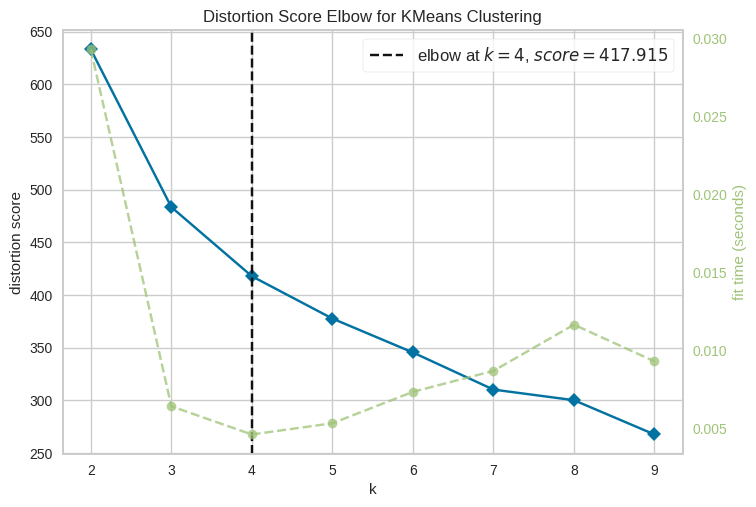

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
kmeans = KMeans()

visualizer = KElbowVisualizer(kmeans, k=(2,10))
visualizer.fit(dcs_df)
visualizer.show()

In [23]:
# Menggunakan algoritma K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(dcs_df)

labels = kmeans.labels_

k = 4

dcs_df['Cluster'] = labels

def analyze_clusters(dcs_df, labels, k):
  print("Analisis Karakteristik Setiap Cluster:")
  for cluster_id in range(k):
    cluster_data = dcs_df[labels == cluster_id]

    mean_transaksi = cluster_data['TransactionAmount_capped'].mean()
    mean_saldo = cluster_data['AccountBalance'].mean()
    mean_usia = cluster_data['CustomerAge'].mean()
    mean_duration = cluster_data['TransactionDuration'].mean()
    mean_login = cluster_data['LoginAttempts'].mean()

    print(f"Cluster {cluster_id + 1}:")
    print(f"Rata-rata Transaksi: {mean_transaksi}")
    print(f"Rata-rata Saldo: {mean_saldo}")
    print(f"Rata-rata usia: {mean_usia}")
    print(f"Rata-rata durasi transaksi: {mean_duration}")
    print(f"Rata-rata jumlah login: {mean_login}")

analyze_clusters(dcs_df, labels, k)

Analisis Karakteristik Setiap Cluster:
Cluster 1:
Rata-rata Transaksi: 0.7823556120494641
Rata-rata Saldo: 0.33879416895996073
Rata-rata usia: 0.4235162520465188
Rata-rata durasi transaksi: 0.3750287949323915
Rata-rata jumlah login: 0.003842478842478843
Cluster 2:
Rata-rata Transaksi: 0.18120111911527334
Rata-rata Saldo: 0.46032379146580377
Rata-rata usia: 0.6150294712317819
Rata-rata durasi transaksi: 0.38018284400728514
Rata-rata jumlah login: 0.0032440435359217088
Cluster 3:
Rata-rata Transaksi: 0.2925878975988285
Rata-rata Saldo: 0.37602189423108
Rata-rata usia: 0.4691022153128644
Rata-rata durasi transaksi: 0.4282509347735771
Rata-rata jumlah login: 0.7801204819277109
Cluster 4:
Rata-rata Transaksi: 0.20502283636024957
Rata-rata Saldo: 0.13890287196025686
Rata-rata usia: 0.1388737116818397
Rata-rata durasi transaksi: 0.3699956046330606
Rata-rata jumlah login: 0.008810631823876858


Jalankan cell code ini untuk menyimpan model kamu.

In [24]:
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [25]:
# Menghitung dan menampilkan nilai Silhouette Score.
score = silhouette_score(dcs_df, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5982661825036328


/tmp/ipython-input-26-3658045475.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean_use['Cluster'] = labels


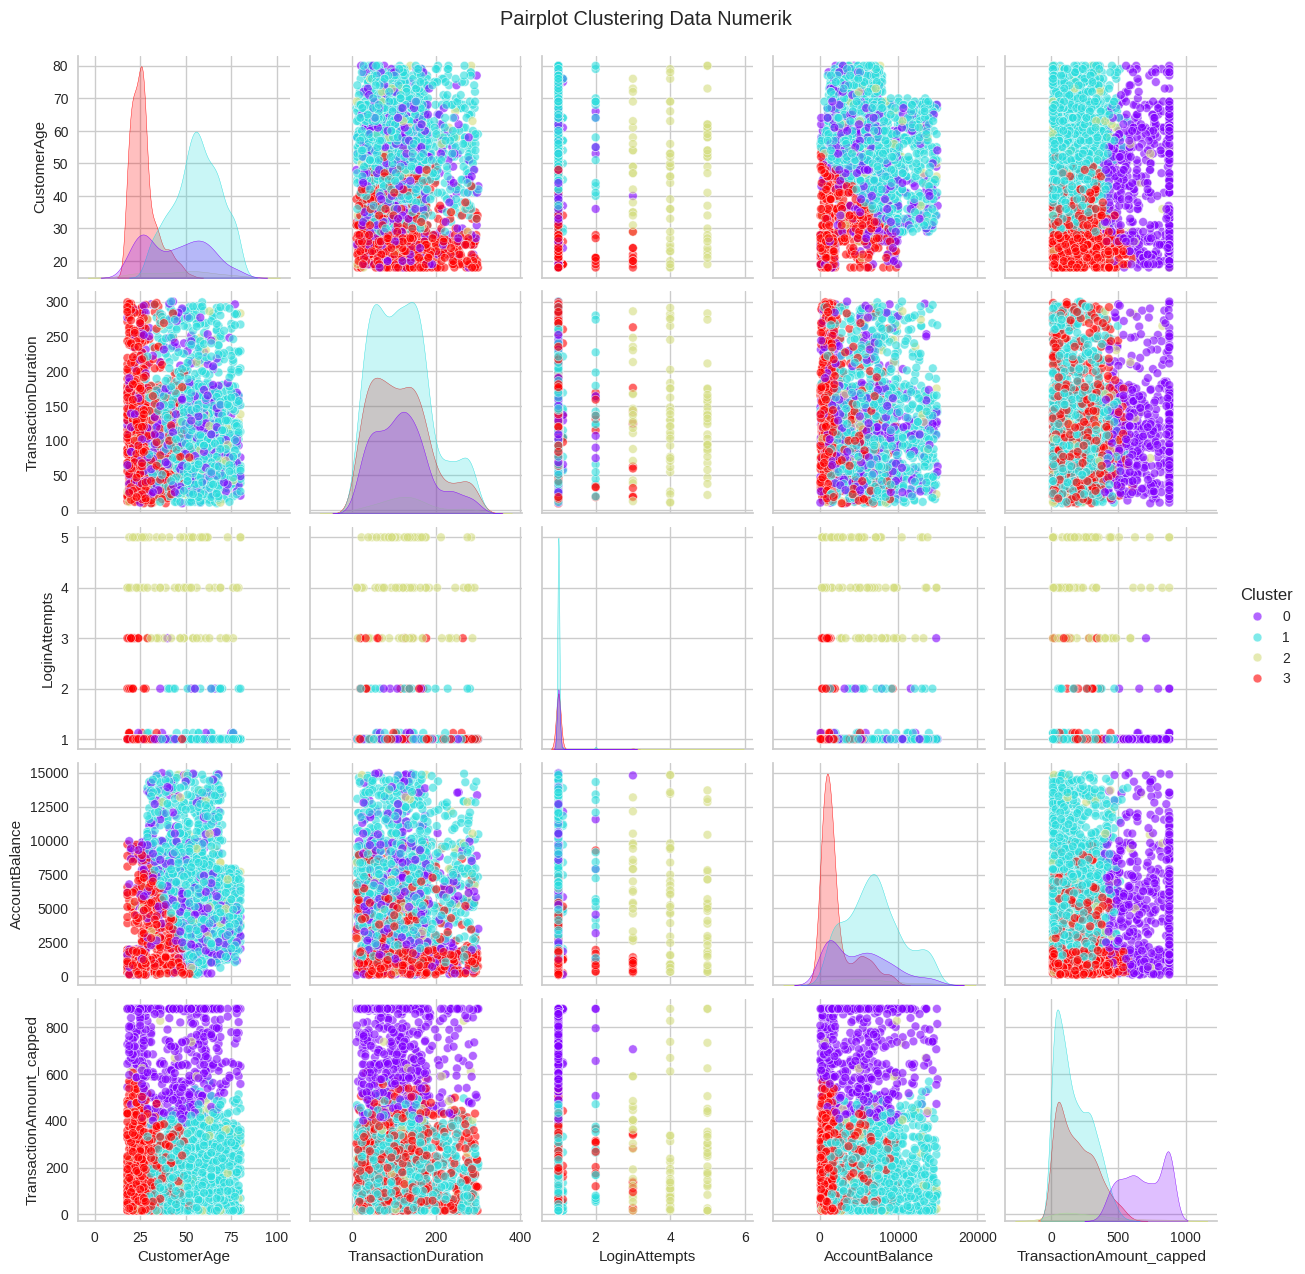

In [26]:
# Membuat visualisasi hasil clustering
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

data_clean_use['Cluster'] = labels

# Buat pairplot
sns.pairplot(
    data_clean_use,
    vars=['CustomerAge','TransactionDuration','LoginAttempts','AccountBalance','TransactionAmount_capped'],
    hue='Cluster',
    palette='rainbow',
    plot_kws={'alpha': 0.6, 's': 40}  # transparansi & ukuran titik
)

plt.suptitle('Pairplot Clustering Data Numerik', y=1.02)  # judul
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [27]:
# Membangun model menggunakan PCA.
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca_result = pca.fit_transform(dcs_df)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
k_means = KMeans(n_clusters= 5)
k_means.fit(pca_df)

KMeans(n_clusters=5)

In [28]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(k_means, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [29]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
dcs_df.groupby('Cluster').agg(['mean', 'min', 'max'])

CustomerAge                    AccountBalance                      \
               mean      min       max           mean       min       max   
Cluster                                                                     
0          0.423516  0.00000  1.000000       0.338794  0.000064  1.000000   
1          0.615029  0.16129  1.000000       0.460324  0.001320  0.997633   
2          0.469102  0.00000  1.000000       0.376022  0.014640  0.991483   
3          0.138874  0.00000  0.580645       0.138903  0.000000  0.646340   

        TransactionAmount_capped                     LoginAttempts             \
                            mean       min       max          mean  min   max   
Cluster                                                                         
0                       0.782356  0.426038  1.000000      0.003842  0.0  0.50   
1                       0.181201  0.000000  0.639849      0.003244  0.0  0.25   
2                       0.292588  0.000000  1.000000      0.780120  0.5  1.00   
3                       0.205023  0.000000  0.683587      0.008811  0.0  0.50   

        TransactionDuration                      
                       mean       min       max  
Cluster                                          
0                  0.375029  0.000000  1.000000  
1                  0.380183  0.000000  1.000000  
2                  0.428251  0.003448  0.968966  
3                  0.369996  0.000000  0.996552

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 0: (Produktif dan Aktivitas Transaksi Tinggi)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 0.42<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 0.33<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 0.78<Setelah inverse>
  - **Analisis:** Cluster ini terdiri dari usia paruh baya dengan saldo sedang namun sangat aktif bertransaksi. Cocok ditargetkan untuk produk keuangan yang mendukung aktivitas transaksi yang lebih tinggi(misalnya: cashback, sistem poin).

2. **Cluster 1: (Lansia Pasif)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 0.61<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 0.46<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 0.18<Setelah inverse>
  - **Analisis:** Cluster ini diisi pengguna lansia dengan saldo cukup namun aktivitas transaksi rendah. Cocok diberikan layanan simpel dan aman seperti tabungan pensiun atau layanan pelanggan personal.

3. **Cluster 2: (Paruh Baya dengan Daya Beli Tinggi)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 0.46<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 0.37<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 0.29<Setelah inverse>
  - **Analisis:** Cluster ini diisi kelompok usia matang dengan saldo besar namun jarang transaksi yang diberikan dilakukan dengan jumlah minim atau jarang bertransaksi. Berpotensi besar sebagai investor atau pengguna layanan premium(wealth management, deposito, atau reksadana).

4. **Cluster 3: (Milenial Awal dengan Aktivitas Rendah)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 0.13<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 0.13<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 0.20<Setelah inverse>
  - **Analisis:** Cluster ini diisi pengguna muda dengan saldo dan frekeuensi dan transaksi rendah. Perlu strategi engagement seperti reward referral.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [30]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
data_clean_clustered = dcs_df.rename(columns={'Cluster': 'Target'})
data_clean_clustered.head()

,CustomerAge,AccountBalance,TransactionAmount_capped,LoginAttempts,TransactionDuration,Target
0,0.838710,0.336832,0.000000,0.0,0.244828,1
1,0.806452,0.918055,0.417768,0.0,0.451724,1
2,0.016129,0.068637,0.127858,0.0,0.158621,3
3,0.129032,0.569198,0.195374,0.0,0.051724,3
4,0.430297,0.492591,0.000000,0.0,0.648276,1


In [31]:
# Simpan Data
data_clean_clustered.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [32]:
# inverse dataset ke rentang normal untuk numerikal
kmeans= KMeans(n_clusters=4, random_state=42)
kmeans.fit(dcs_df)

labels = kmeans.labels_

scaler = min_max_scaler.fit_transform(data_clean_use)

data_numerik_inverse = min_max_scaler.inverse_transform(scaler)

data_numerik_inverse_df = pd.DataFrame(data_numerik_inverse, columns=dcs_df.columns)
data_numerik_inverse_df['Target'] = labels

data_numerik_inverse_df.drop('Cluster', axis=1, inplace=True)

# tampilkan dataset yang sudah di-inverse
data_numerik_inverse_df.head()

,CustomerAge,AccountBalance,TransactionAmount_capped,LoginAttempts,TransactionDuration,Target
0,70.000000,5112.21,16.055,1.0,81.0,2
1,68.000000,13758.91,376.240,1.0,141.0,3
2,19.000000,1122.35,126.290,1.0,56.0,1
3,26.000000,8569.06,184.500,1.0,25.0,1
4,44.678444,7429.40,16.055,1.0,198.0,3


In [33]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
# for ___ in categorical_cols:
#     ___ = encoders[col]
#     df[col] = ___.inverse_transform(df_inverse[col].astype(int))
# tampilkan dataset yang sudah di-inverse
# ___.head()

In [34]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.
data_numerik_inverse_df.groupby('Target').agg(['mean', 'min', 'max'])

CustomerAge             AccountBalance                     \
              mean   min   max           mean      min       max   
Target                                                             
0        44.258008  18.0  80.0    5141.402765   102.20  14977.99   
1        26.592655  18.0  54.0    2172.796561   101.25   9716.68   
2        62.653003  41.0  80.0    4592.633706   120.89   9385.57   
3        47.529061  28.0  70.0   10051.444972  5298.85  14942.78   

       TransactionAmount_capped                  LoginAttempts            \
                           mean      min     max          mean  min  max   
Target                                                                     
0                    690.574626  383.370  878.22      1.015370  1.0  3.0   
1                    194.808201   16.055  878.22      1.138136  1.0  5.0   
2                    177.769246   16.055  878.22      1.179841  1.0  5.0   
3                    176.123234   16.055  827.14      1.124264  1.0  5.0   

       TransactionDuration               
                      mean   min    max  
Target                                   
0               118.758351  10.0  300.0  
1               117.634837  10.0  299.0  
2               116.443345  10.0  293.0  
3               127.046482  10.0  300.0

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 1: (Produktif dan Aktivitas Transaksi Tinggi)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 44.25<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse>5141.40<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse>690.57<Setelah inverse>
  - **Analisis:** Cluster ini terdiri dari usia paruh baya dengan saldo sedang namun sangat aktif bertransaksi. Cocok ditargetkan untuk produk keuangan yang mendukung aktivitas transaksi yang lebih tinggi(misalnya: cashback, sistem poin).

2. **Cluster 2: (Milenial Awal dengan Aktivitas Rendah)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 26.59<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 2172.79<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 194.80<Setelah inverse>
  - **Analisis:** Cluster ini diisi pengguna muda dengan saldo dan frekeuensi dan transaksi rendah. Perlu strategi engagement seperti reward referral.

3. **Cluster 3: (Lansia Pasif)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 62.65<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 4592.63<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 177.76<Setelah inverse>
  - **Analisis:** Cluster ini diisi pengguna lansia dengan saldo cukup namun aktivitas transaksi rendah. Cocok diberikan layanan simpel dan aman seperti tabungan pensiun atau layanan pelanggan personal.

4. **Cluster 4: (Paruh Baya dengan Daya Beli Tinggi)**:
  - **Rata-rata Usia(mean) <Fitur>:** <Sebelum inverse> 47.52<Setelah inverse>
  - **Rata-rata Saldo(mean) <Fitur>:** <Sebelum inverse> 10051.44<Setelah inverse>
  - **Rata-rata Transaksi(mean) <Fitur>:** <Sebelum inverse> 176.12<Setelah inverse>
  - **Analisis:** Cluster ini diisi kelompok usia matang dengan saldo besar namun jarang transaksi yang diberikan dilakukan dengan jumlah minim atau jarang bertransaksi. Berpotensi besar sebagai investor atau pengguna layanan premium(wealth management, deposito, atau reksadana).

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [35]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
data_numerik_inverse_df['Cluster'] = kmeans.labels_
data_numerik_inverse_df.head(5)

,CustomerAge,AccountBalance,TransactionAmount_capped,LoginAttempts,TransactionDuration,Target,Cluster
0,70.000000,5112.21,16.055,1.0,81.0,2,2
1,68.000000,13758.91,376.240,1.0,141.0,3,3
2,19.000000,1122.35,126.290,1.0,56.0,1,1
3,26.000000,8569.06,184.500,1.0,25.0,1,1
4,44.678444,7429.40,16.055,1.0,198.0,3,3


In [36]:
# Simpan Data
data_numerik_inverse_df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.